In [67]:
# === Árbol de Decisión para predecir ocupación mensual ===
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# --- 1️⃣ Cargar y preparar el dataset ---
df = pd.read_csv("data/hotel_bookings.csv")

# Variables numéricas a convertir
num_cols = [
    "lead_time","stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies","adr","total_of_special_requests"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Orden lógico de meses
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"],
                                          categories=month_order, ordered=True)

In [68]:
# --- 2️⃣ Crear variable de ocupación mensual (target) ---
group_cols = ["hotel","arrival_date_year","arrival_date_month"]

ocup = (
    df.groupby(group_cols)
      .size()
      .reset_index(name="ocupacion")  # ← target
)

agg = (
    df.groupby(group_cols)
      .agg({
          "lead_time":"mean",
          "adr":"mean",
          "stays_in_week_nights":"mean",
          "stays_in_weekend_nights":"mean",
          "adults":"mean",
          "children":"mean",
          "babies":"mean",
          "total_of_special_requests":"mean"
      })
      .reset_index()
)

data = ocup.merge(agg, on=group_cols, how="inner")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_172\3197251111.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_172\3197251111.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_cols)


In [69]:
# --- 3️⃣ Codificar y preparar features ---
data["hotel"] = data["hotel"].map({"City Hotel":0, "Resort Hotel":1}).astype(int)
data["month_num"] = data["arrival_date_month"].cat.codes + 1
data["arrival_date_year"] = pd.to_numeric(data["arrival_date_year"], errors="coerce")

features = [
    "hotel","arrival_date_year","month_num",
    "lead_time","adr",
    "stays_in_week_nights","stays_in_weekend_nights",
    "adults","children","babies","total_of_special_requests"
]
target = "ocupacion"

model_df = data[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
# --- 4️⃣ Entrenar el árbol de decisión ---
tree_reg = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=8,              # podés ajustar este valor
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [71]:
# --- 5️⃣ Evaluar el modelo ---
y_pred = tree_reg.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Árbol de Decisión -> R²: {r2:.3f} | RMSE: {rmse:.1f}")

Árbol de Decisión -> R²: 0.610 | RMSE: 499.7


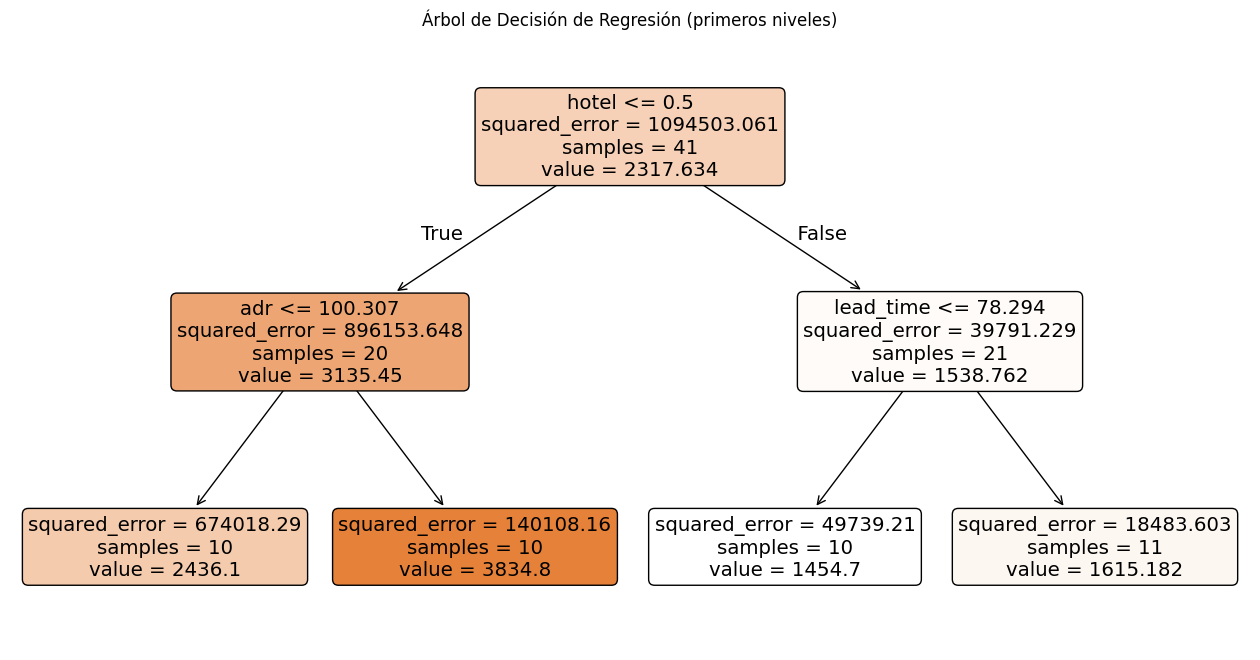

In [72]:
# --- 7️⃣ Visualizar árbol (primeros niveles) ---
plt.figure(figsize=(16,8))
plot_tree(tree_reg, feature_names=features, filled=True, rounded=True, max_depth=3)
plt.title("Árbol de Decisión de Regresión (primeros niveles)")
plt.show()